In [5]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.cuda.amp import GradScaler

In [6]:



IMG_SIZE    = 32           # reduced from 64
BATCH_SIZE  = 8
T           = 200
BETA_START  = 1e-4
BETA_END    = 0.02
EPOCHS      = 15
LR          = 2e-4
DATA_DIR    = "/kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs/train"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"GPUs available: {torch.cuda.device_count()}")

Using device: cuda
GPUs available: 2


In [7]:
import os
print(os.listdir("/kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs/"))

['valid', 'train']


In [8]:
class CelebADataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.image_paths = []
        for fname in os.listdir(root_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                self.image_paths.append(os.path.join(root_dir, fname))
        print(f"Found {len(self.image_paths)} images")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset     = CelebADataset(DATA_DIR, transform=transform)
subset_size = int(0.3 * len(dataset))
dataset     = torch.utils.data.Subset(dataset, range(subset_size))
dataloader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=False)
print(f"Using {subset_size} images, {len(dataloader)} batches per epoch")

Found 27000 images
Using 8100 images, 1013 batches per epoch


In [9]:
class DDPMScheduler:
    def __init__(self, T=T, beta_start=BETA_START, beta_end=BETA_END):
        self.T = T
        
        # Linear noise schedule: beta increases from small to large over T steps
        self.betas = torch.linspace(beta_start, beta_end, T).to(DEVICE)
        
        # Pre-compute values needed for forward & reverse process
        self.alphas            = 1.0 - self.betas
        self.alpha_cumprod     = torch.cumprod(self.alphas, dim=0)          # ᾱ_t
        self.alpha_cumprod_prev = F.pad(self.alpha_cumprod[:-1], (1, 0), value=1.0)  # ᾱ_{t-1}
        
        self.sqrt_alpha_cumprod        = torch.sqrt(self.alpha_cumprod)
        self.sqrt_one_minus_alpha_cumprod = torch.sqrt(1.0 - self.alpha_cumprod)
        
    def add_noise(self, x0, t, noise=None):
        """Forward process: q(x_t | x_0) — add noise to clean image"""
        if noise is None:
            noise = torch.randn_like(x0)
        
        # Gather the right timestep values for each sample in the batch
        sqrt_alpha   = self.sqrt_alpha_cumprod[t].view(-1, 1, 1, 1)
        sqrt_one_minus = self.sqrt_one_minus_alpha_cumprod[t].view(-1, 1, 1, 1)
        
        # x_t = sqrt(ᾱ_t) * x_0  +  sqrt(1 - ᾱ_t) * ε
        return sqrt_alpha * x0 + sqrt_one_minus * noise, noise

    def sample_timesteps(self, batch_size):
        """Randomly sample a timestep for each image in the batch"""
        return torch.randint(0, self.T, (batch_size,), device=DEVICE)

scheduler = DDPMScheduler()
print("Scheduler ready")
print(f"Beta range: {scheduler.betas[0]:.5f} → {scheduler.betas[-1]:.5f}")

Scheduler ready
Beta range: 0.00010 → 0.02000


In [10]:
# ── Time Embedding ───────────────────────────────────────────────────────
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.proj = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.SiLU(),
            nn.Linear(dim * 4, dim * 4)
        )

    def forward(self, t):
        half = self.dim // 2
        emb  = math.log(10000) / (half - 1)
        emb  = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb  = t[:, None].float() * emb[None, :]
        emb  = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return self.proj(emb)


# ── Residual Block (fixed GroupNorm) ─────────────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        in_groups  = min(8, in_ch)
        out_groups = min(8, out_ch)
        self.norm1     = nn.GroupNorm(in_groups, in_ch)
        self.conv1     = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2     = nn.GroupNorm(out_groups, out_ch)
        self.conv2     = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_proj = nn.Linear(time_dim, out_ch)
        self.act       = nn.SiLU()
        self.skip      = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.act(self.norm1(x))
        h = self.conv1(h)
        h = h + self.time_proj(self.act(t_emb))[:, :, None, None]
        h = self.act(self.norm2(h))
        h = self.conv2(h)
        return h + self.skip(x)


# ── Downsample / Upsample ────────────────────────────────────────────────
class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 4, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.ConvTranspose2d(ch, ch, 4, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)

print("Building blocks defined")

Building blocks defined


In [11]:
class UNet(nn.Module):
    def __init__(self, in_ch=3, base_ch=64, time_dim=128):
        super().__init__()
        self.time_dim = time_dim
        self.time_emb = TimeEmbedding(time_dim)

        # ── Encoder ─────────────────────────────────────────
        self.enc1 = ResBlock(in_ch, base_ch, time_dim * 4)         # 3   → 64
        self.enc2 = ResBlock(base_ch, base_ch, time_dim * 4)       # 64  → 64
        self.down1 = Downsample(base_ch)                            # 128x128 → 64x64

        self.enc3 = ResBlock(base_ch, base_ch * 2, time_dim * 4)   # 64  → 128
        self.enc4 = ResBlock(base_ch * 2, base_ch * 2, time_dim * 4)
        self.down2 = Downsample(base_ch * 2)                        # 64x64 → 32x32

        self.enc5 = ResBlock(base_ch * 2, base_ch * 4, time_dim * 4)  # 128 → 256
        self.enc6 = ResBlock(base_ch * 4, base_ch * 4, time_dim * 4)
        self.down3 = Downsample(base_ch * 4)                           # 32x32 → 16x16

        # ── Bottleneck ───────────────────────────────────────
        self.mid1 = ResBlock(base_ch * 4, base_ch * 4, time_dim * 4)
        self.mid2 = ResBlock(base_ch * 4, base_ch * 4, time_dim * 4)

        # ── Decoder ─────────────────────────────────────────
        self.up1   = Upsample(base_ch * 4)                             # 16x16 → 32x32
        self.dec1  = ResBlock(base_ch * 8, base_ch * 4, time_dim * 4) # 512 → 256 (skip concat)
        self.dec2  = ResBlock(base_ch * 4, base_ch * 2, time_dim * 4) # 256 → 128

        self.up2   = Upsample(base_ch * 2)                             # 32x32 → 64x64
        self.dec3  = ResBlock(base_ch * 4, base_ch * 2, time_dim * 4) # 256 → 128 (skip concat)
        self.dec4  = ResBlock(base_ch * 2, base_ch, time_dim * 4)     # 128 → 64

        self.up3   = Upsample(base_ch)                                 # 64x64 → 128x128
        self.dec5  = ResBlock(base_ch * 2, base_ch, time_dim * 4)     # 128 → 64 (skip concat)
        self.dec6  = ResBlock(base_ch, base_ch, time_dim * 4)

        # ── Output ──────────────────────────────────────────
        self.out_norm = nn.GroupNorm(8, base_ch)
        self.out_conv = nn.Conv2d(base_ch, in_ch, 1)  # predicts noise: same shape as input

    def forward(self, x, t):
        # 1. Time embedding
        t_emb = self.time_emb(t)                    # (B, time_dim*4)

        # 2. Encoder
        e1 = self.enc1(x,  t_emb)
        e2 = self.enc2(e1, t_emb)
        e3 = self.enc3(self.down1(e2), t_emb)
        e4 = self.enc4(e3, t_emb)
        e5 = self.enc5(self.down2(e4), t_emb)
        e6 = self.enc6(e5, t_emb)

        # 3. Bottleneck
        b  = self.down3(e6)
        b  = self.mid1(b, t_emb)
        b  = self.mid2(b, t_emb)

        # 4. Decoder (concat skip connections from encoder)
        d  = self.up1(b)
        d  = self.dec1(torch.cat([d, e6], dim=1), t_emb)
        d  = self.dec2(d, t_emb)

        d  = self.up2(d)
        d  = self.dec3(torch.cat([d, e4], dim=1), t_emb)
        d  = self.dec4(d, t_emb)

        d  = self.up3(d)
        d  = self.dec5(torch.cat([d, e2], dim=1), t_emb)
        d  = self.dec6(d, t_emb)

        # 5. Output
        return self.out_conv(F.silu(self.out_norm(d)))


# Initialize model & wrap for dual GPU
model     = UNet().to(DEVICE)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
    print(f"Using {torch.cuda.device_count()} GPUs")

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
scaler    = GradScaler()

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

Using 2 GPUs
Model parameters: 12,435,785


/tmp/ipykernel_39186/2149870617.py:82: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()


Epoch 1/15: 100%|██████████| 1013/1013 [03:37<00:00,  4.66it/s, loss=0.0337]


Epoch 1/15 — Avg Loss: 0.1045


Epoch 2/15: 100%|██████████| 1013/1013 [03:00<00:00,  5.62it/s, loss=0.0317]


Epoch 2/15 — Avg Loss: 0.0772


Epoch 3/15: 100%|██████████| 1013/1013 [02:58<00:00,  5.69it/s, loss=0.0898]


...

Epoch 13/15 — Avg Loss: 0.0608


Epoch 14/15: 100%|██████████| 1013/1013 [02:57<00:00,  5.70it/s, loss=0.0908]


Epoch 14/15 — Avg Loss: 0.0618


Epoch 15/15: 100%|██████████| 1013/1013 [03:00<00:00,  5.60it/s, loss=0.1165]


Epoch 15/15 — Avg Loss: 0.0609


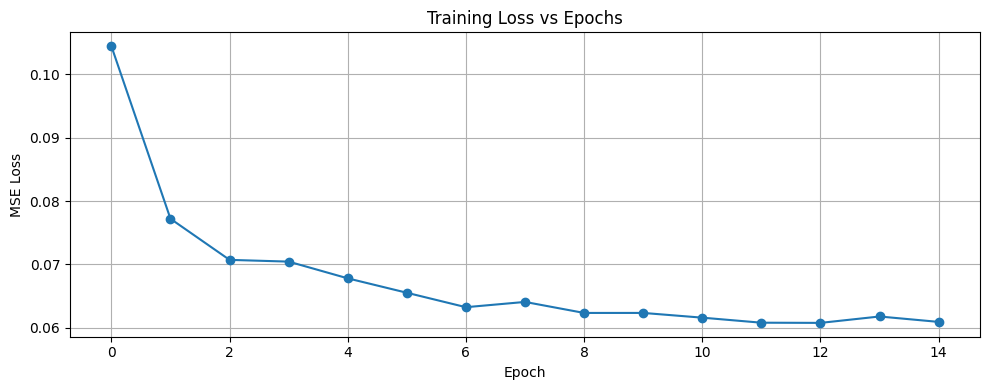

In [12]:
def train(model, dataloader, optimizer, scheduler, scaler, epochs=EPOCHS):
    model.train()
    loss_history = []

    for epoch in range(epochs):
        epoch_loss = 0.0
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")

        for batch in pbar:
            x0 = batch.to(DEVICE)
            B  = x0.shape[0]

            t  = scheduler.sample_timesteps(B)
            x_noisy, noise = scheduler.add_noise(x0, t)

            with torch.amp.autocast('cuda'):
                noise_pred = model(x_noisy, t)
                loss = F.mse_loss(noise_pred, noise)

            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        avg_loss = epoch_loss / len(dataloader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} — Avg Loss: {avg_loss:.4f}")

    return loss_history

# Run training
loss_history = train(model, dataloader, optimizer, scheduler, scaler)

# Plot loss curve
plt.figure(figsize=(10, 4))
plt.plot(loss_history, marker='o')
plt.title("Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_curve.png")
plt.show()

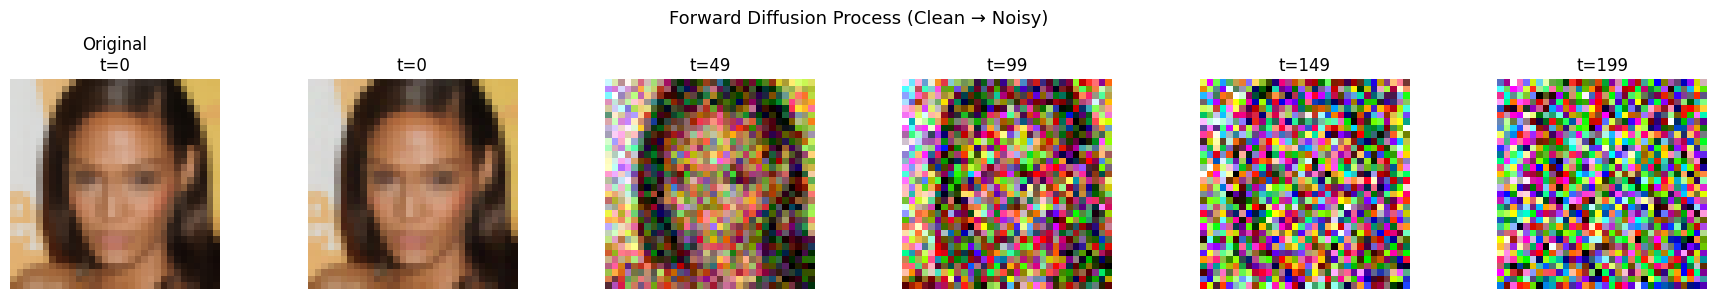

Forward diffusion visualization saved


In [13]:
def visualize_forward_diffusion(scheduler, dataloader, steps=5):
    # Grab one batch and take the first image
    batch  = next(iter(dataloader))
    x0     = batch[0:1].to(DEVICE)          # (1, 3, 128, 128) — single clean image

    # Pick 5 evenly spaced timesteps across T
    timesteps = torch.linspace(0, scheduler.T - 1, steps).long().to(DEVICE)

    fig, axes = plt.subplots(1, steps + 1, figsize=(3 * (steps + 1), 3))

    # Show original clean image
    img_np = x0[0].cpu().permute(1, 2, 0).numpy()
    img_np = (img_np * 0.5 + 0.5).clip(0, 1)   # denormalize [-1,1] → [0,1]
    axes[0].imshow(img_np)
    axes[0].set_title("Original\nt=0")
    axes[0].axis("off")

    # Show noisy versions at each timestep
    for i, t in enumerate(timesteps):
        t_batch          = t.unsqueeze(0)                        # shape (1,)
        x_noisy, _       = scheduler.add_noise(x0, t_batch)     # add noise at step t
        noisy_np         = x_noisy[0].cpu().permute(1, 2, 0).numpy()
        noisy_np         = (noisy_np * 0.5 + 0.5).clip(0, 1)   # denormalize
        axes[i + 1].imshow(noisy_np)
        axes[i + 1].set_title(f"t={t.item()}")
        axes[i + 1].axis("off")

    plt.suptitle("Forward Diffusion Process (Clean → Noisy)", fontsize=13)
    plt.tight_layout()
    plt.savefig("forward_diffusion.png", dpi=150)
    plt.show()
    print("Forward diffusion visualization saved")

visualize_forward_diffusion(scheduler, dataloader, steps=5)

Sampling: 100%|██████████| 200/200 [00:21<00:00,  9.32it/s]


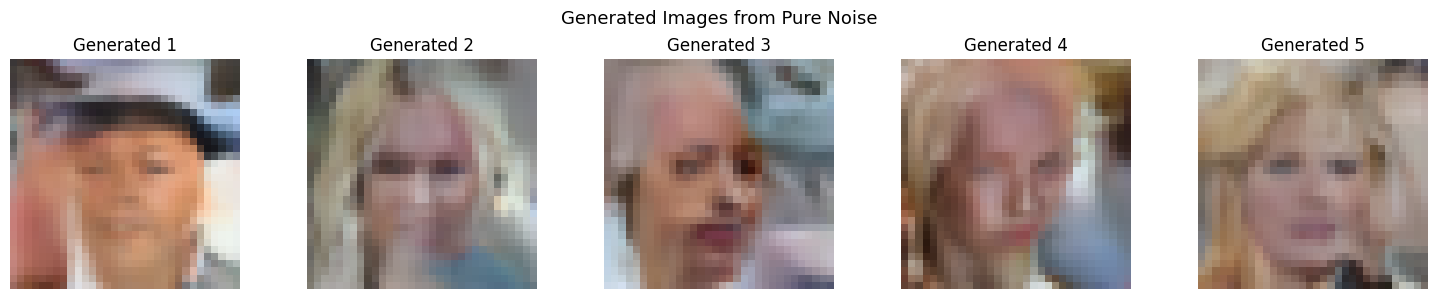

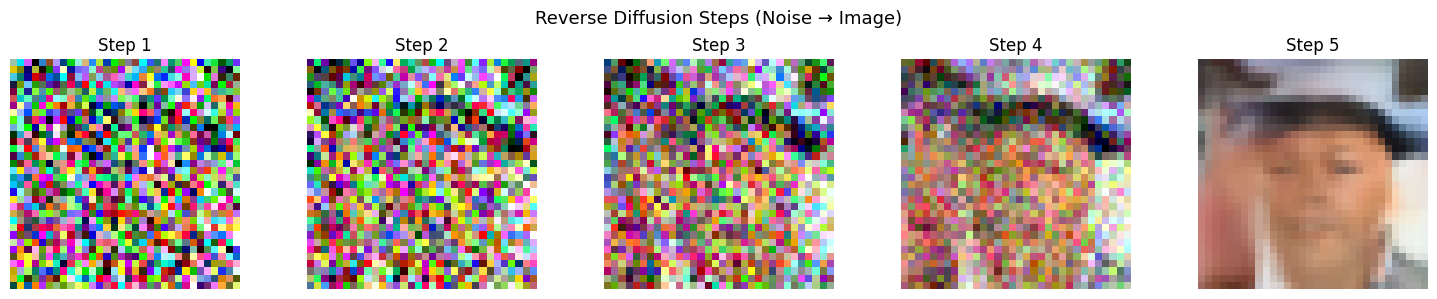

Generation complete — images saved


In [14]:
@torch.no_grad()
def sample(model, scheduler, n_images=5, img_size=IMG_SIZE):
    model.eval()
    
    x = torch.randn(n_images, 3, img_size, img_size).to(DEVICE)
    intermediates = []

    for t_val in tqdm(reversed(range(scheduler.T)), desc="Sampling", total=scheduler.T):
        t_batch = torch.full((n_images,), t_val, device=DEVICE, dtype=torch.long)

        alpha              = scheduler.alphas[t_val]
        alpha_cumprod      = scheduler.alpha_cumprod[t_val]
        alpha_cumprod_prev = scheduler.alpha_cumprod_prev[t_val]
        beta               = scheduler.betas[t_val]

        with torch.amp.autocast('cuda'):
            noise_pred = model(x, t_batch)

        coef1  = 1.0 / torch.sqrt(alpha)
        coef2  = beta / torch.sqrt(1.0 - alpha_cumprod)
        x_prev = coef1 * (x - coef2 * noise_pred)

        if t_val > 0:
            noise    = torch.randn_like(x)
            variance = torch.sqrt(beta * (1.0 - alpha_cumprod_prev) / (1.0 - alpha_cumprod))
            x_prev   = x_prev + variance * noise

        x = x_prev

        if t_val % (scheduler.T // 5) == 0:
            intermediates.append(x.clone().cpu())

    return x.cpu(), intermediates


def show_generated(images, intermediates, n=5):
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    for i in range(n):
        img = images[i].permute(1, 2, 0).numpy()
        img = (img * 0.5 + 0.5).clip(0, 1)
        axes[i].imshow(img)
        axes[i].set_title(f"Generated {i+1}")
        axes[i].axis("off")
    plt.suptitle("Generated Images from Pure Noise", fontsize=13)
    plt.tight_layout()
    plt.savefig("generated_images.png", dpi=150)
    plt.show()

    fig, axes = plt.subplots(1, len(intermediates), figsize=(3 * len(intermediates), 3))
    for i, img_tensor in enumerate(intermediates):
        img = img_tensor[0].permute(1, 2, 0).numpy()
        img = (img * 0.5 + 0.5).clip(0, 1)
        axes[i].imshow(img)
        axes[i].set_title(f"Step {i+1}")
        axes[i].axis("off")
    plt.suptitle("Reverse Diffusion Steps (Noise → Image)", fontsize=13)
    plt.tight_layout()
    plt.savefig("reverse_steps.png", dpi=150)
    plt.show()
    print("Generation complete — images saved")


# Run sampling
generated, intermediates = sample(model, scheduler, n_images=5)
show_generated(generated, intermediates)

  Average PSNR : 10.2099 dB
  Average SSIM : 0.0764
  Image 1 — PSNR: 8.63 dB | SSIM: 0.0212
  Image 2 — PSNR: 12.21 dB | SSIM: 0.1345
  Image 3 — PSNR: 9.65 dB | SSIM: 0.0678
  Image 4 — PSNR: 10.76 dB | SSIM: 0.0936
  Image 5 — PSNR: 9.80 dB | SSIM: 0.0650


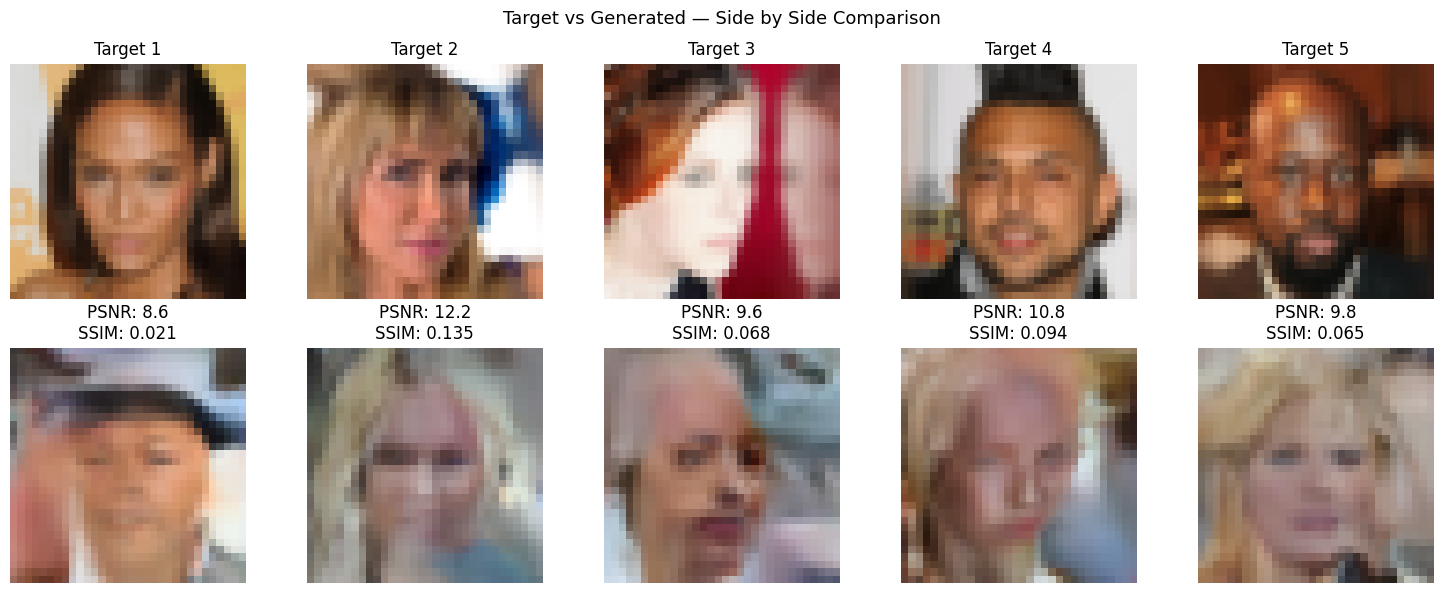

Comparison saved


In [15]:
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn

def tensor_to_numpy(tensor):
    """Convert a single image tensor (3, H, W) in [-1,1] to numpy (H, W, 3) in [0,1]"""
    img = tensor.permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)
    return img

def compute_metrics(real_imgs, gen_imgs):
    """Compute average PSNR and SSIM between real and generated images"""
    psnr_scores = []
    ssim_scores = []

    for real, gen in zip(real_imgs, gen_imgs):
        real_np = tensor_to_numpy(real)
        gen_np  = tensor_to_numpy(gen)

        psnr_scores.append(psnr_fn(real_np, gen_np, data_range=1.0))
        ssim_scores.append(ssim_fn(real_np, gen_np,
                                   data_range=1.0, channel_axis=2))

    avg_psnr = np.mean(psnr_scores)
    avg_ssim = np.mean(ssim_scores)
    return avg_psnr, avg_ssim, psnr_scores, ssim_scores


# ── Reconstruction Task ──────────────────────────────────────────────────
# Grab 5 real images from dataset as reconstruction targets
batch      = next(iter(dataloader))
target_imgs = batch[0:5]                     # (5, 3, 128, 128) — our target images

# Compute metrics between targets and generated images
avg_psnr, avg_ssim, psnr_list, ssim_list = compute_metrics(target_imgs, generated)

print("=" * 40)
print(f"  Average PSNR : {avg_psnr:.4f} dB")
print(f"  Average SSIM : {avg_ssim:.4f}")
print("=" * 40)
for i, (p, s) in enumerate(zip(psnr_list, ssim_list)):
    print(f"  Image {i+1} — PSNR: {p:.2f} dB | SSIM: {s:.4f}")


# ── Side-by-side Comparison ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i in range(5):
    # Top row: target images
    target_np = tensor_to_numpy(target_imgs[i])
    axes[0, i].imshow(target_np)
    axes[0, i].set_title(f"Target {i+1}")
    axes[0, i].axis("off")

    # Bottom row: generated images
    gen_np = tensor_to_numpy(generated[i])
    axes[1, i].imshow(gen_np)
    axes[1, i].set_title(f"PSNR: {psnr_list[i]:.1f}\nSSIM: {ssim_list[i]:.3f}")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Target", fontsize=12)
axes[1, 0].set_ylabel("Generated", fontsize=12)

plt.suptitle("Target vs Generated — Side by Side Comparison", fontsize=13)
plt.tight_layout()
plt.savefig("reconstruction_comparison.png", dpi=150)
plt.show()
print("Comparison saved")

In [1]:
from pypdf import PdfReader

pdf_path = r"d:\Work\A4GENAI\GenAI_Assignment04.pdf"
reader = PdfReader(pdf_path)
print("pages:", len(reader.pages))
for i, page in enumerate(reader.pages[:5], start=1):
    text = page.extract_text() or ""
    print(f"\n--- PAGE {i} ---\n")
    print(text[:4000])


pages: 5

--- PAGE 1 ---

 
 
 
National University of Computer and Emerging Sciences 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
Assignment No. 4 
 
Generative AI 
 
AI4009 
Spring 2026 
 
 
 


--- PAGE 2 ---

Submission Instructions: 
● Submit the complete .ipynb file, which should be named AI_ASS01_XXF_YYYY, 
where XX represents the batch and YYYY represents the roll number.  
● Submit a Word file containing the GitHub repository link, as well as the Medium 
and LinkedIn post links 
● This is a group assignment (max 2 members allowed). 
● Any submission not following the submission instructions will not be evaluated. 
● Explore the Datasets completely before starting to code. 
● You can explore more datasets if needed and must explain your reasoning of using 
them but there is a constraint attached datasets must need to be used. 
● Submit your own work. Accept your current limitations. Grow from your 
mistakes. 
● Plagiarism is strictly prohibited and lead to Straight Zero (^_^). 
 
 
Questio

In [2]:
from pypdf import PdfReader

pdf_path = r"d:\Work\A4GENAI\GenAI_Assignment04.pdf"
out_path = r"d:\Work\A4GENAI\assignment04_extracted.txt"
reader = PdfReader(pdf_path)
all_text = []
for i, page in enumerate(reader.pages, start=1):
    text = page.extract_text() or ""
    all_text.append(f"\n--- PAGE {i} ---\n{text}\n")
with open(out_path, "w", encoding="utf-8") as f:
    f.write("\n".join(all_text))
print("wrote", out_path)
print("pages:", len(reader.pages))
print("chars:", sum(len(t) for t in all_text))


wrote d:\Work\A4GENAI\assignment04_extracted.txt
pages: 5
chars: 5375
